# Bandung House Price Prediction

**Bandung House Price Prediction** is a regression task aimed at estimating property prices based on key housing features such as the number of bedrooms, bathrooms, land area, and building size.

In [1]:
# Importing Libraries
import pandas as pd

In [2]:
# Importing dataset
df = pd.read_csv('../data/data.csv')
df.head()

,Rumah,Premier,"Rp 2,1 Miliar",Cicilan: 7 Jutaan per bulan,"Rumah 2 Lantai Bagus Sertifikat Hak Milik di Maltra Residence, Bandung","Andir, Bandung",3,2,2.1,137 m²,170 m²
0,Rumah,NaN,"Rp 4,1 Miliar",Cicilan: 15 Jutaan per bulan,Rumah Cantik @ Andir (Sudirman),"Andir, Bandung",3,2,3,202 m²,300 m²
1,Rumah,NaN,"Rp 3,3 Miliar",Cicilan: 12 Jutaan per bulan,Jual Cepat Rumah di Maleber Rajawali Bisa Untu...,"Andir, Bandung",5,2,1,350 m²,258 m²
2,Rumah,NaN,Rp 580 Juta,Cicilan: 2 Jutaan per bulan,Rumah minimalis 3 lantai di andir Bandung coco...,"Andir, Bandung",2,2,1,30 m²,80 m²
3,Rumah,NaN,"Rp 1,3 Miliar",Cicilan: 4 Jutaan per bulan,Jual Rumah Murah Bisa Dijadikan Kos”an Di Jala...,"Andir, Bandung",11,3,0,176 m²,176 m²
4,Rumah,NaN,"Rp 3,6 Miliar",Cicilan: 13 Jutaan per bulan,"Rumah 2,5 Lantai Strategis SHM di Komplek Kert...","Andir, Bandung",5,3,1,184 m²,234 m²


# Data Preprocessing Part 1

In [3]:
# Checking the shape of dataset
df.shape

(7610, 11)

In [4]:
# Removed unused column
un_col = ['Rumah', 'Premier', 'Cicilan: 7 Jutaan per bulan']
df.drop(un_col, axis=1, inplace=True)
df.columns

Index(['Rp 2,1 Miliar',
       'Rumah 2 Lantai Bagus Sertifikat Hak Milik di Maltra Residence, Bandung',
       'Andir, Bandung', '3', '2', '2.1', '137 m²', '170 m²'],
      dtype='object')

In [5]:
# Rename column
df.rename(columns={'Rp 2,1 Miliar': 'price',  
                   'Rumah 2 Lantai Bagus Sertifikat Hak Milik di Maltra Residence, Bandung' : 'name', 
                   'Andir, Bandung' : 'location',
                   '3' : 'bedroom',
                   '2' : 'bathroom',
                   '2.1' : 'carport',
                   '137 m²' : 'land_size',
                   '170 m²' : 'building_size',
                  }, 
          inplace=True)
df.columns

Index(['price', 'name', 'location', 'bedroom', 'bathroom', 'carport',
       'land_size', 'building_size'],
      dtype='object')

In [6]:
# Check duplicate
df.duplicated().sum()

np.int64(616)

In [7]:
# Remove duplicate
df.drop_duplicates(inplace=True)

## Property Type Labeling

After exploring the dataset, some listings were identified as invalid property types based on their name (e.g., not actual houses). So i use a simple text classification approach to categorize them.

a rule-based text classification approach was applied to automatically categorize listings:

1. Listings containing words like **“rumah”** or **“rmh”** were labeled as `house`.
2. Any record initially labeled as `house` but containing commercial keywords 
   such as **“kost”**, **“ruko”**, **“villa”**, or **“hotel”** was reclassified as `non_house`.

This simple rule-based approach was chosen intentionally because the main goal of this project 
is to **build a price prediction model**, not to develop a complex text classification system.  
Therefore, an efficient and interpretable filtering method was sufficient to separate 
residential (`house`) listings from commercial (`non_house`) ones before modeling.

While this approach effectively distinguishes most property types, it has one limitation:  
**listings that do not explicitly mention “rumah” or any known property type** (e.g., titles containing only 
marketing terms or locations) **cannot be accurately detected** and may remain misclassified.

In [8]:
import numpy as np

# Make new column 'type' as property type and fill the values base on column 'name' that contains 'rumah'/'rmh' word as 'house'
df['type'] = np.where(df['name'].str.contains('rumah|rmh' , case=False, na=False), 
                               'house', 
                               'non_house')

In [9]:
# a word that usually signifies not a house
keywords_non_house = ['ruko', 'kost', 'kos ', 'kos' , 'hotel', 'villa', 'gedung', 'penginapan', 'apartemen']

# override the incorrect results
mask_house = df['type'] == 'house'
mask_invalid = df['name'].str.contains('|'.join(keywords_non_house), case=False, na=False)

# change the type into 'non_house' if the conditions are True
df.loc[mask_house & mask_invalid, 'type'] = 'non_house'

df['type'].value_counts()

type
house        6250
non_house     744
Name: count, dtype: int64

In [10]:
df[df['type'] == 'non_house'].head(5)

,price,name,location,bedroom,bathroom,carport,land_size,building_size,type
3,"Rp 1,3 Miliar",Jual Rumah Murah Bisa Dijadikan Kos”an Di Jala...,"Andir, Bandung",11,3,0,176 m²,176 m²,non_house
46,"Rp 2,57 Miliar",Strategis Ruko 2 Lantai Area Rajawali Garuda A...,"Andir, Bandung",4,2,2,134 m²,220 m²,non_house
48,Rp 3 Miliar,Dijual Rumaah di Lugina Andir,"Andir, Bandung",2,1,1,240 m²,200 m²,non_house
53,Rp 400 Juta,Rumah ex kos2 an jl Maleber Barat,"Andir, Bandung",5,3,0,56 m²,95 m²,non_house
95,"Rp 2,25 Miliar",Rumah Kost 3 Lantai Di Ciroyom Andir Bandung,"Andir, Bandung",11,5,0,163 m²,300 m²,non_house


In [11]:
# Remove non-house listings row
df = df[df['type'] != 'non_house']

## String & Numeric Format Cleaning

In [12]:
# Make new Price column
df['price_clean'] = (
    df['price']
    .str.replace('[^0-9,\.]', '', regex=True)   
    .str.replace(',', '.', regex=False)         
)

# change Price data type to numeric
df['price_clean'] = pd.to_numeric(df['price_clean'], errors='coerce')


# If Condition for 'Miliar' and 'Juta'
df.loc[df['price'].str.contains('miliar', case=False, na=False), 'price_clean'] = df['price_clean'] * 1_000_000_000
df.loc[df['price'].str.contains('juta', case=False, na=False), 'price_clean'] = df['price_clean'] * 1_000_000

In [13]:
# Make new land_size column
df['land_size_clean'] = (
    df['land_size']
    .astype(str)                                  
    .str.replace('[^0-9,\.]', '', regex=True)     
    .str.replace(',', '.', regex=False)          
)

# Change land_size data type to numeric
df['land_size_clean'] = pd.to_numeric(df['land_size_clean'], errors='coerce')

In [14]:
# Make new building_size column
df['building_size_clean'] = (
    df['building_size']
    .astype(str)                                  
    .str.replace('[^0-9,\.]', '', regex=True)     
    .str.replace(',', '.', regex=False)          
)

# change building_size data type to numeric
df['building_size_clean'] = pd.to_numeric(df['building_size_clean'], errors='coerce')

In [15]:
# Removed unused columns
un_col = ['name', 'location','price', 'land_size', 'building_size', 'type']
df.drop(un_col, axis=1, inplace=True)
df.columns

Index(['bedroom', 'bathroom', 'carport', 'price_clean', 'land_size_clean',
       'building_size_clean'],
      dtype='object')

In [16]:
# Check data type
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6250 entries, 0 to 7609
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   bedroom              6250 non-null   int64  
 1   bathroom             6250 non-null   int64  
 2   carport              6250 non-null   int64  
 3   price_clean          6250 non-null   float64
 4   land_size_clean      6249 non-null   float64
 5   building_size_clean  6250 non-null   int64  
dtypes: float64(2), int64(4)
memory usage: 470.8 KB


In [17]:
# check missing values
df.isnull().sum()

bedroom                0
bathroom               0
carport                0
price_clean            0
land_size_clean        1
building_size_clean    0
dtype: int64

In [18]:
# delete missing values
df.dropna(inplace=True)

In [19]:
# checking number of unique value of each column
df.nunique()

bedroom                 24
bathroom                17
carport                 19
price_clean            639
land_size_clean        699
building_size_clean    432
dtype: int64

In [20]:
#checking the unique values in each column
cols = df.columns
for i in cols:
    print(i, df[i].unique(), '\n')

bedroom [ 3  5  2  4  6  7  0  9  8  1 12 13 11 10 19 14 18 16 15 27 23 24 29 40] 

bathroom [ 2  3  1  5  0  4  7 11  6 10  8  9 13 17 12 14 40] 

carport [ 3  1  2  6  7  0  4  5  8 10 30  9 15 20 13 16 12 11 14] 

price_clean [4.10e+09 3.30e+09 5.80e+08 3.60e+09 1.17e+09 2.90e+09 4.50e+09 2.10e+09
 2.20e+09 1.40e+09 7.00e+09 7.50e+09 5.80e+09 3.50e+09 1.50e+09 8.00e+09
 6.50e+08 3.90e+09 1.20e+09 1.10e+09 2.75e+09 1.05e+10 2.30e+09 8.75e+08
 5.50e+09 1.75e+09 1.80e+09 4.25e+09 6.00e+08 2.65e+08 2.35e+09 5.00e+08
 5.50e+08 1.25e+09 1.60e+09 1.19e+10 6.50e+09 2.00e+09 9.00e+09 8.90e+09
 1.35e+09 3.50e+10 4.00e+09 1.58e+09 1.10e+10 3.25e+08 5.30e+09 2.50e+09
 9.99e+08 1.99e+09 1.00e+09 3.70e+09 5.00e+09 3.95e+09 4.75e+09 1.30e+09
 1.55e+09 4.95e+09 1.50e+10 6.25e+09 8.50e+09 1.90e+10 2.60e+08 3.00e+09
 1.70e+10 1.24e+09 7.90e+09 3.25e+09 1.65e+09 4.20e+09 8.90e+08 5.60e+09
 9.50e+09 2.30e+10 1.15e+09 8.00e+08 1.98e+09 1.70e+09 2.10e+10 8.25e+09
 1.90e+09 5.40e+09 3.10e+09 1.85e+10 6.57

In [21]:
df.describe()

,bedroom,bathroom,carport,price_clean,land_size_clean,building_size_clean
count,6249.000000,6249.000000,6249.000000,6.249000e+03,6249.000000,6.249000e+03
mean,3.761402,2.645383,1.324372,4.753621e+09,254.152504,7.118963e+02
std,2.070665,1.495949,1.623466,1.563327e+10,319.882564,3.802398e+04
min,0.000000,0.000000,0.000000,2.200000e+07,22.000000,1.000000e+00
25%,3.000000,2.000000,0.000000,1.100000e+09,100.000000,1.000000e+02
50%,3.000000,2.000000,1.000000,2.150000e+09,162.000000,1.700000e+02
75%,4.000000,3.000000,2.000000,4.500000e+09,300.000000,3.000000e+02
max,40.000000,40.000000,30.000000,7.350000e+11,9597.000000,3.006000e+06


In [22]:
(df['bedroom'] == 0).sum(), (df['bathroom'] == 0).sum()

(np.int64(150), np.int64(127))

In [23]:
df= df[(df['bedroom'] != 0) & (df['bathroom'] != 0)]

After conducting an initial exploration, it was found that the bedroom and bathroom columns had a minimum value of 0, which is logically impossible for a house. Sample checks showed that the data was not for shop houses or warehouses, but rather for high-priced residential properties, so the value 0 in both columns was considered an input error or incorrectly filled missing value. Therefore, rows with a bedroom or bathroom value of 0 were deleted so that the analysis and model would not be biased by invalid data.

In [24]:
df.describe()

,bedroom,bathroom,carport,price_clean,land_size_clean,building_size_clean
count,6081.000000,6081.000000,6081.000000,6.081000e+03,6081.000000,6.081000e+03
mean,3.854136,2.699720,1.337280,4.680177e+09,252.373787,7.239650e+02
std,2.011056,1.461777,1.613229,1.539222e+10,312.652255,3.854562e+04
min,1.000000,1.000000,0.000000,2.200000e+07,22.000000,1.000000e+00
25%,3.000000,2.000000,0.000000,1.100000e+09,100.000000,1.000000e+02
50%,3.000000,2.000000,1.000000,2.150000e+09,162.000000,1.700000e+02
75%,4.000000,3.000000,2.000000,4.500000e+09,300.000000,3.000000e+02
max,40.000000,40.000000,30.000000,7.350000e+11,9597.000000,3.006000e+06


# EDA
In the exploratory data analysis, I will be visualizing the data to get a better understanding of
the data and to see if there are any trends or pattern in the data. First I will begin with
looking at the distribution of the data and then I will look at the relationship between the
independent variables and the target variable.

## Property Feature

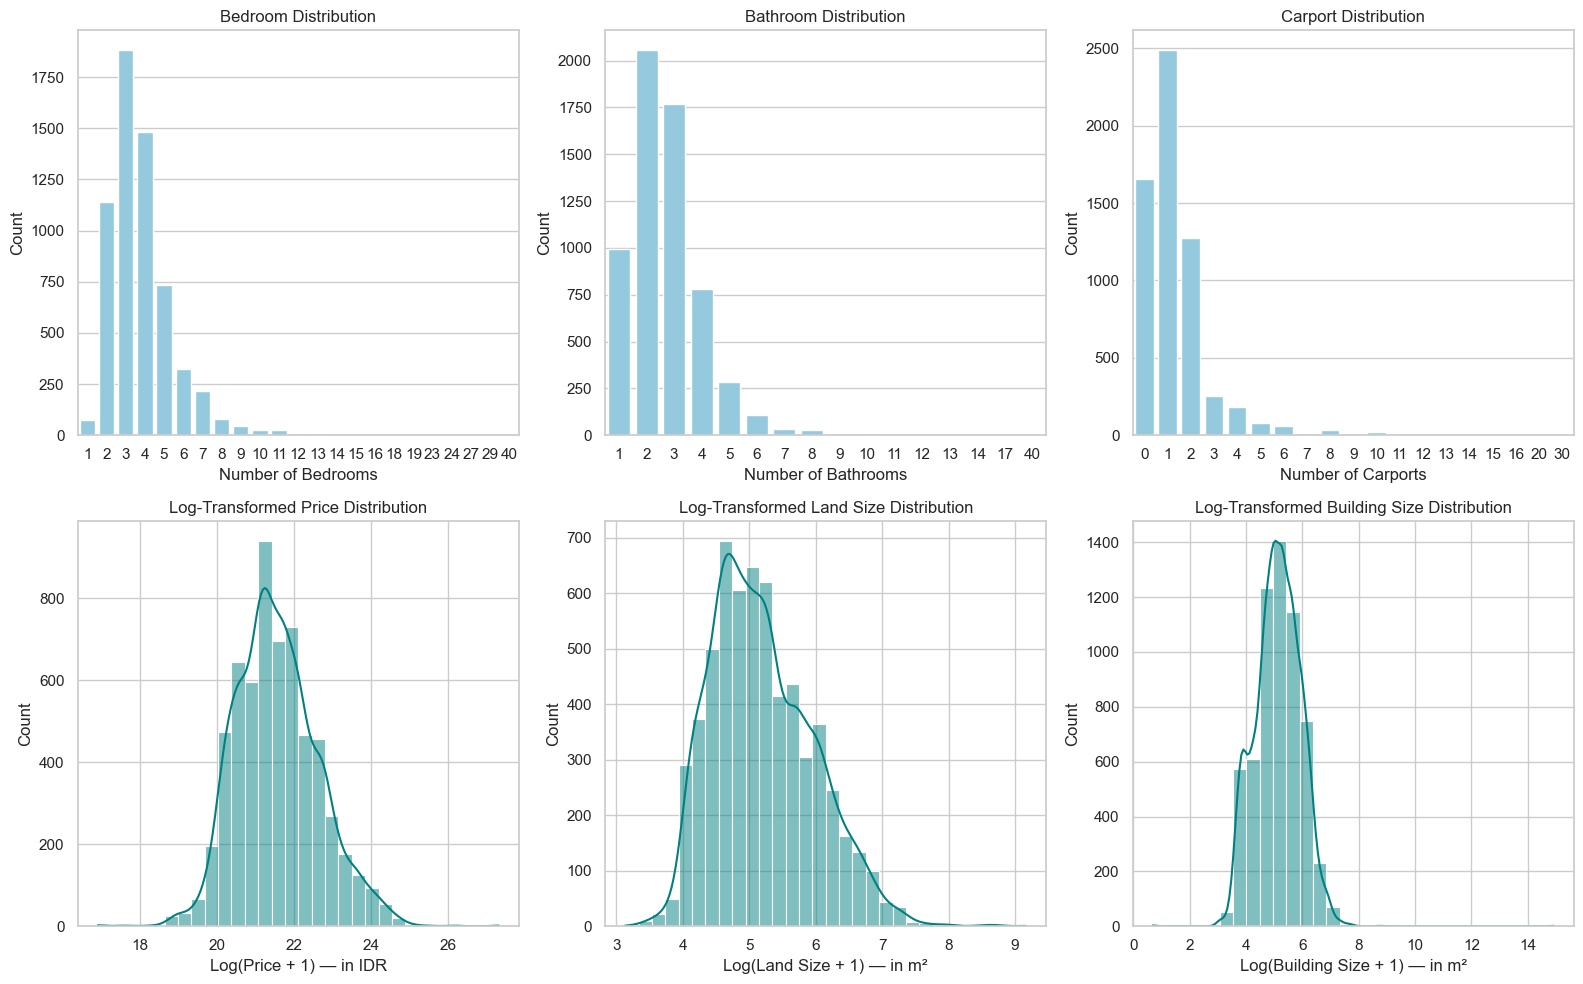

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Set style
sns.set(style="whitegrid")

# Create figure layout (3 rows x 3 columns)
fig, ax = plt.subplots(2, 3, figsize=(16, 10))

# Property Features
sns.countplot(x='bedroom', data=df, ax=ax[0,0], color='skyblue')
ax[0,0].set_title('Bedroom Distribution')
ax[0,0].set_xlabel('Number of Bedrooms')
ax[0,0].set_ylabel('Count')

sns.countplot(x='bathroom', data=df, ax=ax[0,1], color='skyblue')
ax[0,1].set_title('Bathroom Distribution')
ax[0,1].set_xlabel('Number of Bathrooms')
ax[0,1].set_ylabel('Count')

sns.countplot(x='carport', data=df, ax=ax[0,2], color='skyblue')
ax[0,2].set_title('Carport Distribution')
ax[0,2].set_xlabel('Number of Carports')
ax[0,2].set_ylabel('Count')

# ===== Financial Features (Log-transformed) =====
sns.histplot(np.log1p(df['price_clean']), bins=30, kde=True, ax=ax[1,0], color='teal')
ax[1,0].set_title('Log-Transformed Price Distribution')
ax[1,0].set_xlabel('Log(Price + 1) — in IDR')
ax[1,0].set_ylabel('Count')

# ===== Land & Building Size (Log-transformed) =====
sns.histplot(np.log1p(df['land_size_clean']), bins=30, kde=True, ax=ax[1,1], color='teal')
ax[1,1].set_title('Log-Transformed Land Size Distribution')
ax[1,1].set_xlabel('Log(Land Size + 1) — in m²')
ax[1,1].set_ylabel('Count')

sns.histplot(np.log1p(df['building_size_clean']), bins=30, kde=True, ax=ax[1,2], color='teal')
ax[1,2].set_title('Log-Transformed Building Size Distribution')
ax[1,2].set_xlabel('Log(Building Size + 1) — in m²')
ax[1,2].set_ylabel('Count')

plt.tight_layout()
plt.show()

The visualizations above show the distribution of key property related numerical features.
The upper row represents categorical numerical attributes (bedroom, bathroom, and carport counts),
while the lower rows represent continuous attributes (price, land size, and building size) that have been log-transformed to normalize their scales.

1. Bedroom, Bathroom, and Carport:
Most properties have 2–4 bedrooms, 1–3 bathrooms, and 0–2 carports, indicating that the dataset mainly consists of small to medium-sized houses.
A few listings have higher values, suggesting large properties or potential outliers.
2. Price (log-transformed):
After applying a logarithmic transformation, the price distribution appears approximately normal.
This suggests that most properties fall within a moderate price range, while only a few have extremely high prices.
3. Land Size and Building Size (log-transformed):
Both distributions are slightly right-skewed even after transformation,
meaning there are a few properties with significantly larger land and building areas.

Overall, the dataset is dominated by moderately sized, residential houses, with only a small number of luxury or oversized listings.

# Data Preprocessing Part 2

## Outlier

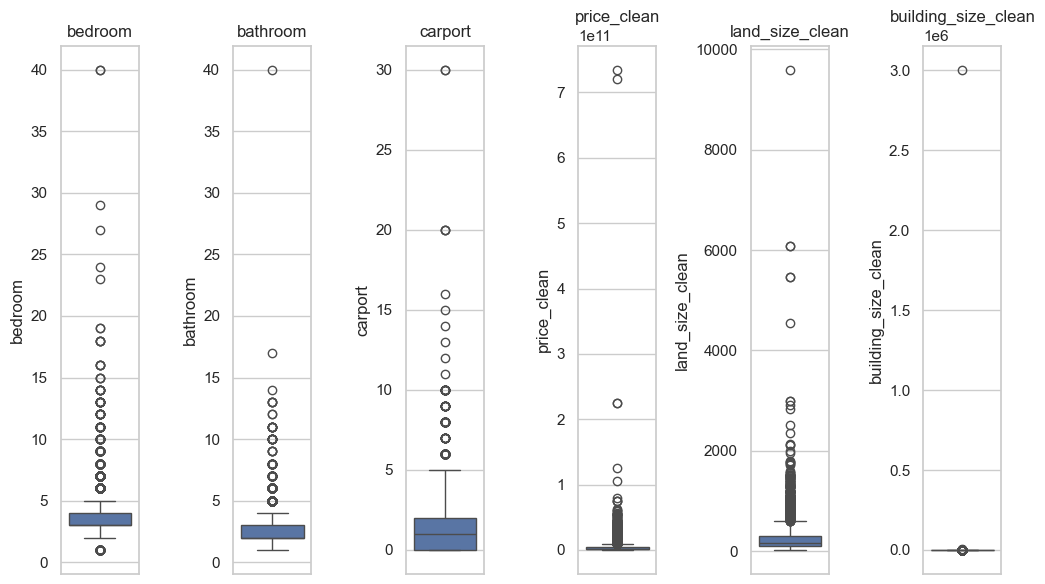

In [26]:
# Check for outlier
numeric_cols = df.columns

plt.figure(figsize=(12, 6))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 7, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [27]:
# Remove outlier using IQR
cols = df.columns

Q3 = df[cols].quantile(0.75)
Q1 = df[cols].quantile(0.25)

IQR = Q3 - Q1

df = df[~((df[cols] < (Q1 - 1.5 * IQR)) |(df[cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

## Correlation Matrix Heatmap

<Axes: >

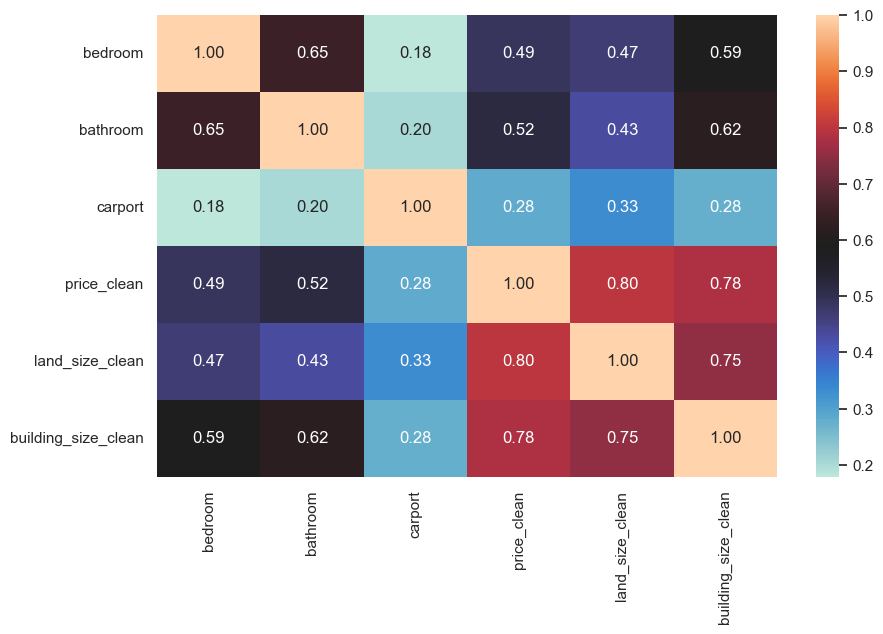

In [28]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='icefire', fmt=".2f")

# Train Test Split

In [29]:
from sklearn.model_selection import train_test_split

#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns='price_clean'), df['price_clean'], test_size=0.2, random_state=42)

## Model Building
Following models to predict the house price:
1. Linear Regression
2. Random Forest Regression
3. XGBoost Regressor

## Linear Regression

### Pipeline

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from datetime import datetime

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# Start timer
start = datetime.now()
print(f"[INFO] started at {start.strftime('%H:%M:%S')}")

# Training the model
pipe.fit(X_train, y_train)

# End timer
end = datetime.now()
print(f"[INFO] ended at {end.strftime('%H:%M:%S')}")

# Compute duration
duration = end - start
total_seconds_lr = duration.total_seconds()
minutes = int(total_seconds_lr // 60)
seconds = int(total_seconds_lr % 60)

print(f"[INFO] Duration: {minutes} min {seconds} seconds")

# Predicting the values
pipe_pred = pipe.predict(X_test)

[INFO] started at 20:29:31
[INFO] ended at 20:29:31
[INFO] Duration: 0 min 0 seconds


Regression Performance Metrics:
MAE  : 639,423,963.56
RMSE : 983,560,649.94
R²    : 0.6987


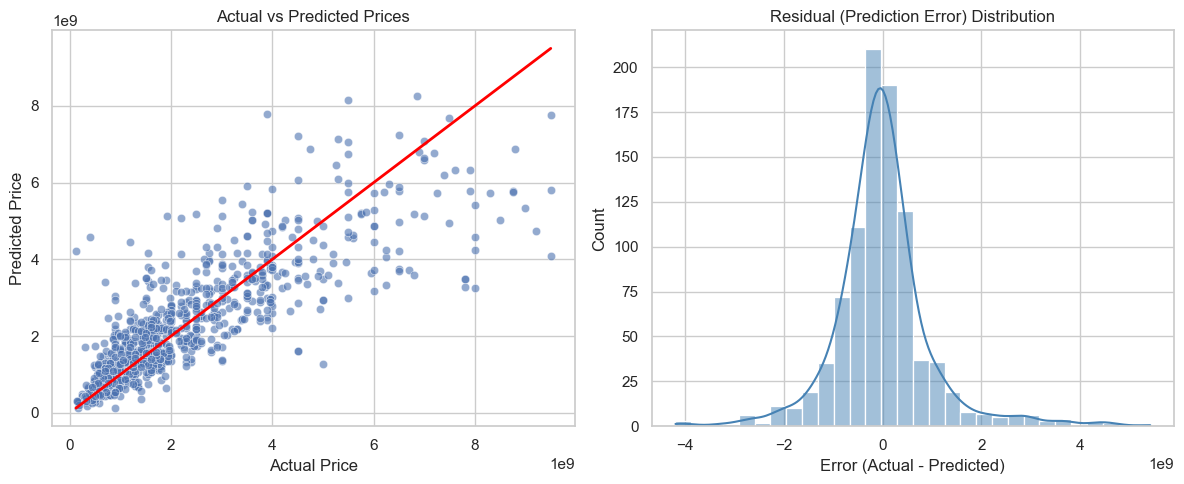

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Test Accuracy
mae_lr = mean_absolute_error(y_test, pipe_pred)
mse_lr = mean_squared_error(y_test, pipe_pred)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, pipe_pred)

print("Regression Performance Metrics:")
print(f"MAE  : {mae_lr:,.2f}")
print(f"RMSE : {rmse_lr:,.2f}")
print(f"R²    : {r2_lr:.4f}")

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=pipe_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

plt.subplot(1, 2, 2)
residuals = y_test - pipe_pred
sns.histplot(residuals, bins=30, kde=True, color='steelblue')
plt.title('Residual (Prediction Error) Distribution')
plt.xlabel('Error (Actual - Predicted)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

## Random Forest Regression

### Hyperparameter Tuning using RandomizedSearchCV

In [32]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

In [33]:
from datetime import datetime
import numpy as np

param_dist_rf = {
    'n_estimators': [200, 500, 800],
    'max_depth': [10, 20, 30],
    'max_features': ['sqrt', 0.8],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

# Create a base model
rf = RandomForestRegressor()

# Create Randomized Search CV
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=10,               
    cv=3,                     
    verbose=2,
    random_state = 42,
    n_jobs=-1                 
)

# Fit the model
rf_random.fit(X_train, y_train)

# Best parameters
print(rf_random.best_params_)

# Save best param + model to best_random_rf
best_random_rf = rf_random.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
{'n_estimators': 800, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.8, 'max_depth': 30}


In [34]:
# Predicting the values
y_pred_rf = best_random_rf.predict(X_test)

# R² Score (Model Accuracy)
r2_test = best_random_rf.score(X_test, y_test)

print(f"Testing  R²: {r2_test:.4f}")

Testing  R²: 0.8063


### Hyperparameter Tuning using GridSearchCV

In [35]:
# Define the Grid Search parameter grid base on best param from Randomized Search
param_grid_rf = {
    'n_estimators': [700, 800, 900],       
    'max_depth': [25, 30, 35],                      
    'max_features': [0.8],                 
    'min_samples_split': [2],                 
    'min_samples_leaf': [1,2],                                                
}

# Create a base model
rf = RandomForestRegressor()

# Create Grid Search CV
rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,               
    cv=3,                     
    verbose=2,                
    n_jobs=-1,    
    scoring = 'r2'
)

# Train the model
rf_grid.fit(X_train, y_train)

# Best parameters
print(rf_grid.best_params_)

# Save best param + model to best_grid_rf
best_grid_rf = rf_grid.best_estimator_

Fitting 3 folds for each of 18 candidates, totalling 54 fits
{'max_depth': 35, 'max_features': 0.8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 900}


In [36]:
# Start timer
start = datetime.now()
print(f"[INFO] started at {start.strftime('%H:%M:%S')}")

# Train the model
best_grid_rf.fit(X_train, y_train)

# End timer
end = datetime.now()
print(f"[INFO] ended at {end.strftime('%H:%M:%S')}")

# Compute duration
duration = end - start
total_seconds_rf = duration.total_seconds()
minutes = int(total_seconds_rf // 60)
seconds = int(total_seconds_rf % 60)

[INFO] started at 20:30:59
[INFO] ended at 20:31:06


In [37]:
# Predicting the values
y_pred_rf = best_grid_rf.predict(X_test)

# R² Score (Model Accuracy)
r2_test = best_grid_rf.score(X_test, y_test)

print(f"Testing  R²: {r2_test:.4f}")

Testing  R²: 0.8062


Random Forest Performance Metrics:
MAE  : 477,194,880.91
RMSE : 788,907,375.64
R²    : 0.8062


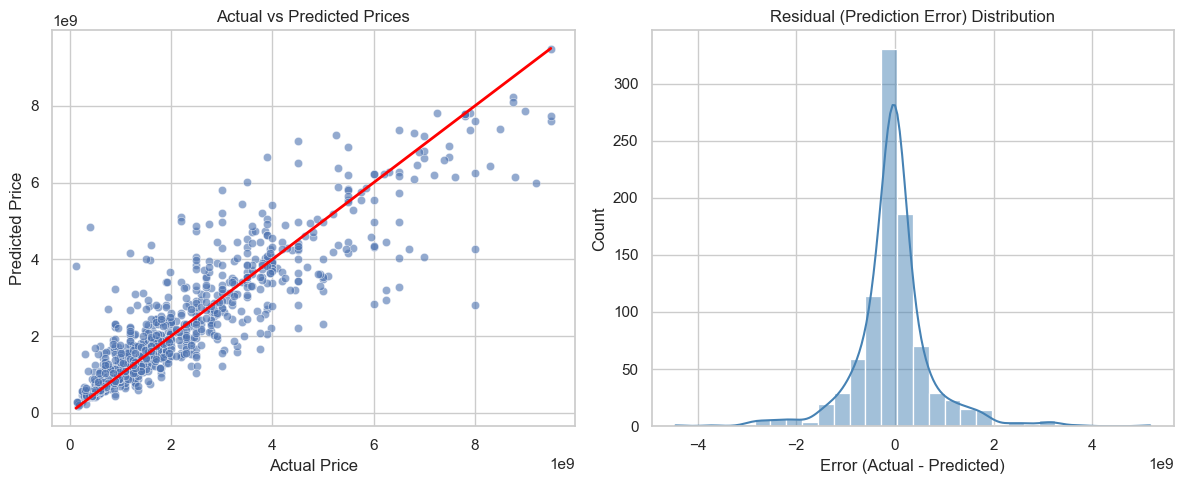

In [38]:
# Test Accuracy
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance Metrics:")
print(f"MAE  : {mae_rf:,.2f}")
print(f"RMSE : {rmse_rf:,.2f}")
print(f"R²    : {r2_rf:.4f}")

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

plt.subplot(1, 2, 2)
residuals = y_test - y_pred_rf
sns.histplot(residuals, bins=30, kde=True, color='steelblue')
plt.title('Residual (Prediction Error) Distribution')
plt.xlabel('Error (Actual - Predicted)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

## XGBoost Regression

### Hyperparameter Tuning using RandomizedSearchCV

In [39]:
from xgboost import XGBRegressor

In [40]:
# Define the Randomized Search parameter grid
param_grid_xgb = {
    'n_estimators': [200, 500, 800],
    'max_depth': [5, 10, 15],
    'min_child_weight': [1, 3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'learning_rate': [0.05, 0.1],
}

# Create a base model
xgb = XGBRegressor()

# Create RandomizedSearch CV
xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid_xgb,
    n_iter=10,              
    cv=3,                     
    verbose=2,                
    random_state=42,
    n_jobs=-1                 
)

# Train the model
xgb_random.fit(X_train, y_train)

# Best parameters
print(xgb_random.best_params_)

# Save best param + model
best_random_xgb = xgb_random.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
{'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [41]:
# Prediksi data test
y_pred_rf = best_random_xgb.predict(X_test)

# R² Score (Model Accuracy)
r2_test = best_random_xgb.score(X_test, y_test)

print(f"Testing  R²: {r2_test:.4f}")

Testing  R²: 0.7765


### Hyperparameter Tuning using GridSearch CV

In [42]:
# Define the Grid Search parameter grid base on best param from Randomized Search
param_grid_xgb = {
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [6, 8, 10],   
    'subsample': [0.8, 1.0],      
    'colsample_bytree': [0.8],
    'min_child_weight': [1, 2],
    'n_estimators': [100, 200, 300]
}

# Create a base model
xgb = XGBRegressor()

# Create Grid Search CV
xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,              
    cv=3,                     
    verbose=2,                
    n_jobs=-1,
    scoring = 'r2'
)

# Fit the model
xgb_grid.fit(X_train, y_train)

# Best parameters
print(xgb_grid.best_params_)

# Save best param + model
best_grid_xgb = xgb_grid.best_estimator_

Fitting 3 folds for each of 108 candidates, totalling 324 fits
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 10, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 0.8}


In [43]:
# Start timer
start = datetime.now()
print(f"[INFO] started at {start.strftime('%H:%M:%S')}")

# Train the model
best_grid_xgb.fit(X_train, y_train)

# End timer
end = datetime.now()
print(f"[INFO] ended at {end.strftime('%H:%M:%S')}")

# Compute duration
duration = end - start
total_seconds_xgb = duration.total_seconds()
minutes = int(total_seconds_xgb // 60)
seconds = int(total_seconds_xgb % 60)

[INFO] started at 20:31:36
[INFO] ended at 20:31:36


In [44]:
# Prediksi data test
y_pred_xgb = best_grid_xgb.predict(X_test)

# R² Score (Model Accuracy)
r2_test = best_grid_xgb.score(X_test, y_test)

print(f"Testing  R²: {r2_test:.4f}")

Testing  R²: 0.7837


XGBoost Performance Metrics:
MAE  : 510,671,955.97
RMSE : 833,356,386.13
R²    : 0.7837


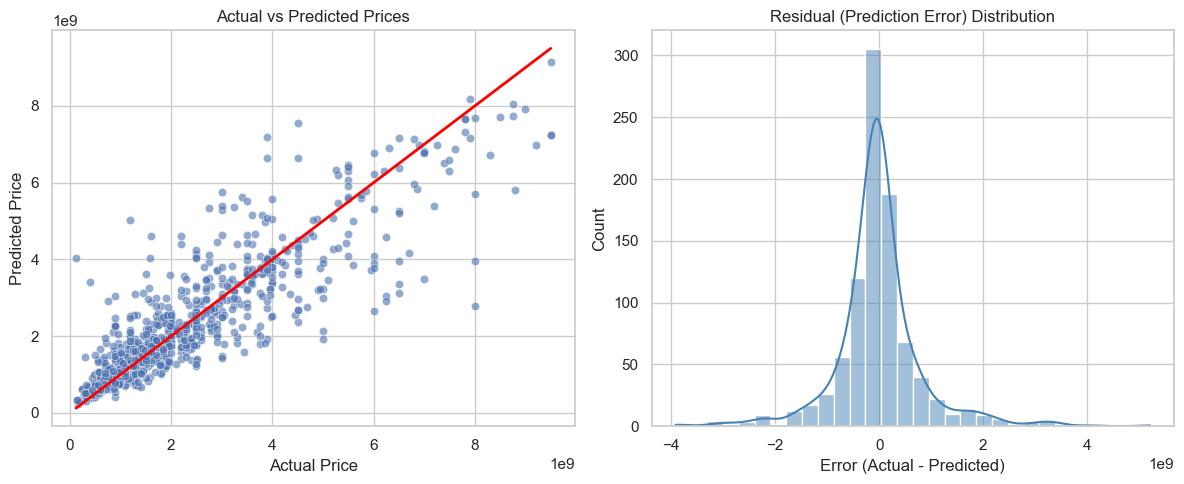

In [45]:
# Test Accuracy
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Performance Metrics:")
print(f"MAE  : {mae_xgb:,.2f}")
print(f"RMSE : {rmse_xgb:,.2f}")
print(f"R²    : {r2_xgb:.4f}")

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_xgb, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

plt.subplot(1, 2, 2)
residuals = y_test - y_pred_xgb
sns.histplot(residuals, bins=30, kde=True, color='steelblue')
plt.title('Residual (Prediction Error) Distribution')
plt.xlabel('Error (Actual - Predicted)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Model Evaluation

## Regression Evaluation Metrics (MAE, RMSE, R2)

In [46]:
# Linear Regression
mae_lr = mean_absolute_error(y_test, pipe_pred)
mse_lr = mean_squared_error(y_test, pipe_pred)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, pipe_pred)

# Random Forest Regression
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# XGBoost Regression
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE': [mae_lr, mae_rf, mae_xgb],
    'RMSE': [rmse_lr, rmse_rf, rmse_xgb],
    'R²': [r2_lr, r2_rf, r2_xgb]
})

results['MAE'] = results['MAE'].apply(lambda x: f"{x:,.2f}")
results['RMSE'] = results['RMSE'].apply(lambda x: f"{x:,.2f}")
results['R²'] = results['R²'].apply(lambda x: f"{x:.4f}")

display(results)

,Model,MAE,RMSE,R²
0,Linear Regression,"639,423,963.56","983,560,649.94",0.6987
1,Random Forest,"507,857,378.67","847,125,747.06",0.7765
2,XGBoost,"510,671,955.97","833,356,386.13",0.7837


## Probability Scatter Plot (Actual vs Predicted)

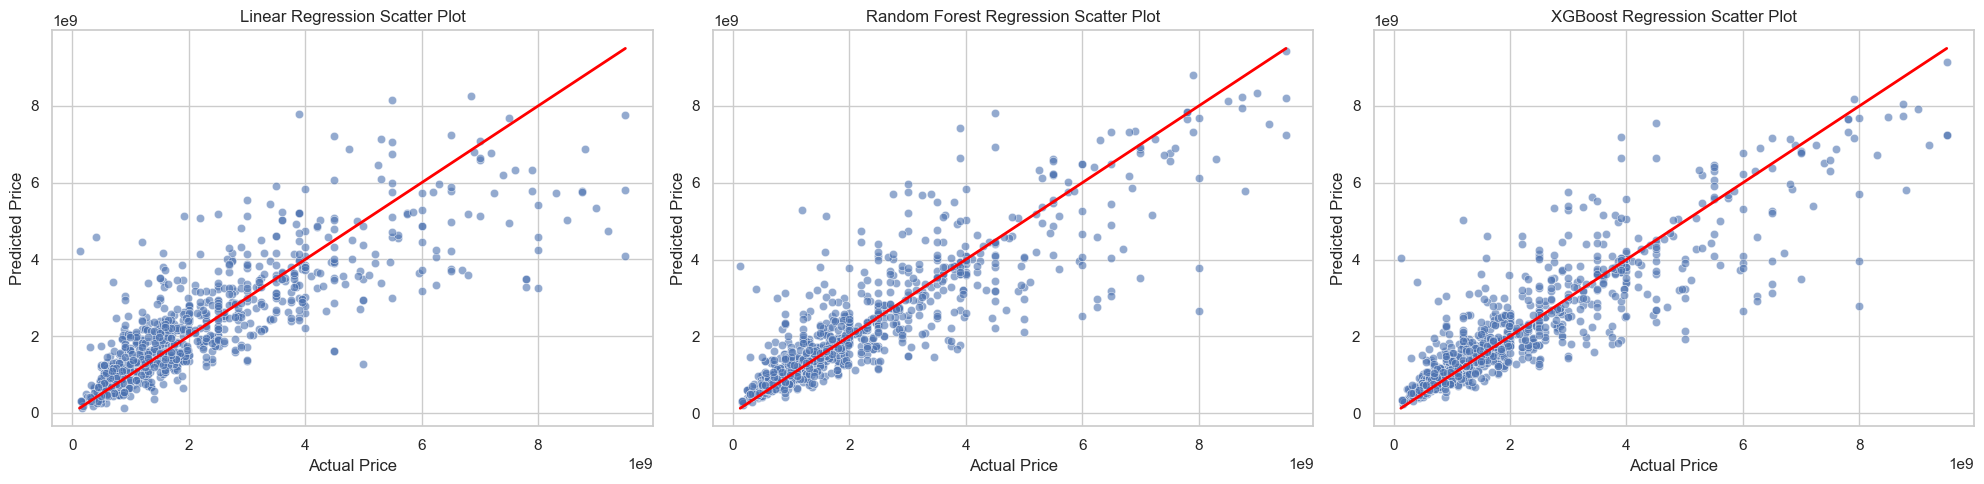

In [47]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

# Linear Regression
sns.scatterplot(x=y_test, y=pipe_pred, alpha=0.6, ax=ax[0])
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
ax[0].set_title('Linear Regression Scatter Plot')
ax[0].set_xlabel('Actual Price')
ax[0].set_ylabel('Predicted Price')

# Random Forest Regression
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6, ax=ax[1])
ax[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
ax[1].set_title('Random Forest Regression Scatter Plot')
ax[1].set_xlabel('Actual Price')
ax[1].set_ylabel('Predicted Price')

# XGBoost Regression
sns.scatterplot(x=y_test, y=y_pred_xgb, alpha=0.6, ax=ax[2])
ax[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
ax[2].set_title('XGBoost Regression Scatter Plot')
ax[2].set_xlabel('Actual Price')
ax[2].set_ylabel('Predicted Price')

plt.tight_layout()
plt.show()

The scatter plots above illustrate the relationship between actual and predicted house prices for three regression models: Linear Regression, Random Forest, and XGBoost.

All three models demonstrate a clear positive correlation between actual and predicted prices, with most data points clustering along the red diagonal line that represents perfect prediction. However, variations in the spread and alignment of points indicate differences in model precision and behavior.

Linear Regression effectively captures the overall price trend but tends to underpredict higher-priced houses, reflecting its limitation in modeling complex nonlinear relationships. Random Forest Regression better captures nonlinear patterns, reducing large errors though still showing slight overestimation in certain price ranges. XGBoost Regression provides the most balanced performance, maintaining tight alignment with the ideal line across nearly all price levels, indicating strong calibration and minimal bias.

Overall, the visualization suggests that XGBoost achieves the most accurate and stable predictions, followed by Random Forest, while Linear Regression remains a simpler yet reliable baseline.

## Probability Distribution Plot (KDE Plot)

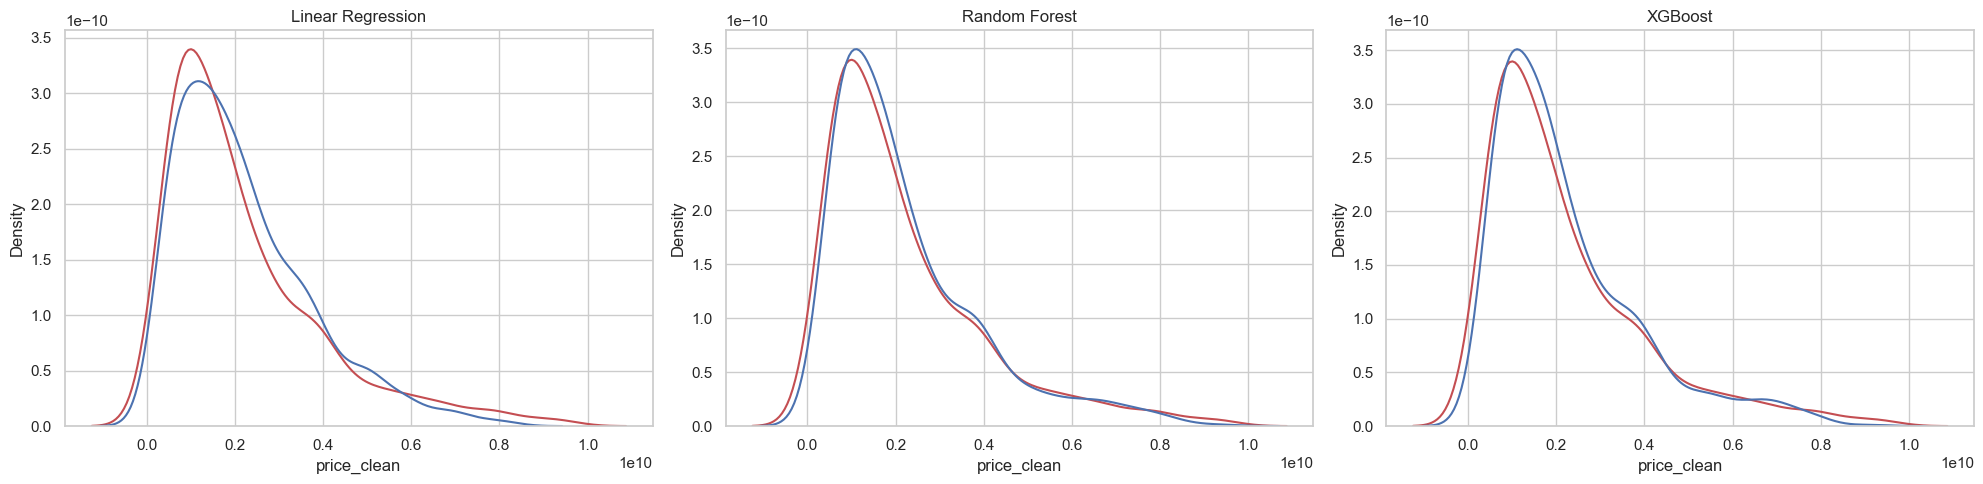

In [48]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

# Logistic Regression
sns.kdeplot(y_test, color="r", label="Actual Value", ax=ax[0])
sns.kdeplot(pipe_pred, color="b", label="Fitted Values", ax=ax[0])
ax[0].set_title('Linear Regression')
ax[0].set_xlabel('price_clean')
ax[0].set_ylabel('Density')

# Random Forest
sns.kdeplot(y_test, color="r", label="Actual Value", ax=ax[1])
sns.kdeplot(y_pred_rf, color="b", label="Fitted Values", ax=ax[1])
ax[1].set_title('Random Forest')
ax[1].set_xlabel('price_clean')
ax[1].set_ylabel('Density')

# XGBoost
sns.kdeplot(y_test, color="r", label="Actual Value", ax=ax[2])
sns.kdeplot(y_pred_xgb, color="b", label="Fitted Values", ax=ax[2])
ax[2].set_title('XGBoost')
ax[2].set_xlabel('price_clean')
ax[2].set_ylabel('Density')

plt.tight_layout()
plt.show()

The following distribution plots compare the actual and predicted house price distributions for each regression model. Among the three, Random Forest Regression achieves the closest alignment with the actual distribution, indicating superior calibration and accuracy across most price ranges. XGBoost Regression also performs well but shows a slightly narrower peak, suggesting mild bias in specific regions. In contrast, Linear Regression produces a broader deviation, especially at higher price levels, reflecting its limitation in modeling nonlinear price dynamics compared to the ensemble-based models.

## Error Evaluation (Residual Distribution / Error vs Predicted Plot)

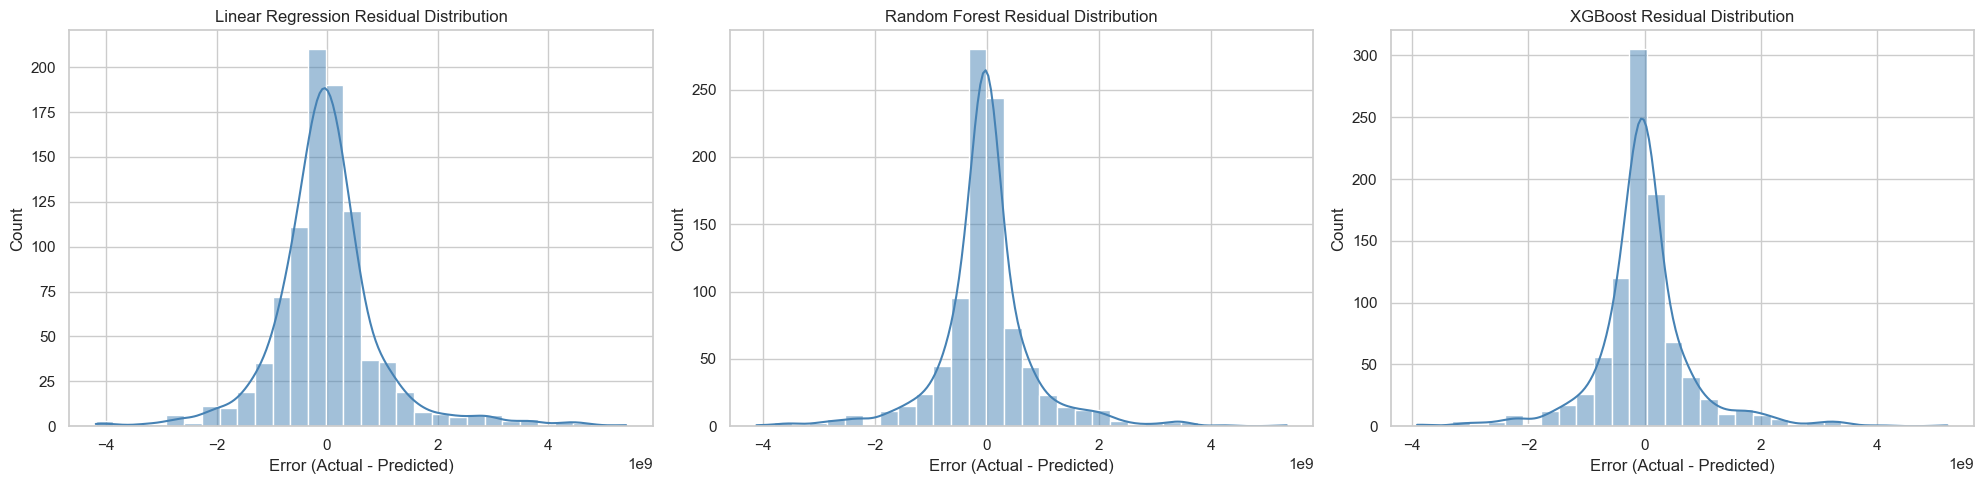

In [49]:
# Residual Distribution Comparison
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

# Linear Regression
residuals_lr = y_test - pipe_pred
sns.histplot(residuals_lr, bins=30, kde=True, color='steelblue', ax=ax[0])
ax[0].set_title('Linear Regression Residual Distribution')
ax[0].set_xlabel('Error (Actual - Predicted)')
ax[0].set_ylabel('Count')

# Random Forest Regression
residuals_rf = y_test - y_pred_rf
sns.histplot(residuals_rf, bins=30, kde=True, color='steelblue', ax=ax[1])
ax[1].set_title('Random Forest Residual Distribution')
ax[1].set_xlabel('Error (Actual - Predicted)')
ax[1].set_ylabel('Count')

# XGBoost Regression
residuals_xgb = y_test - y_pred_xgb
sns.histplot(residuals_xgb, bins=30, kde=True, color='steelblue', ax=ax[2])
ax[2].set_title('XGBoost Residual Distribution')
ax[2].set_xlabel('Error (Actual - Predicted)')
ax[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

The residual plots above illustrate the distribution of prediction errors for the three regression models. All models show residuals centered around zero, indicating unbiased predictions overall. Random Forest and XGBoost exhibit narrower and more symmetrical distributions, suggesting greater stability and consistency in their predictions. In contrast, Linear Regression shows a slightly wider spread, implying higher variance and limited ability to capture nonlinear patterns. Overall, Random Forest and XGBoost demonstrate stronger residual performance and better generalization compared to Linear Regression.

## Train Time Plot

Linear Regression: baseline (same as Linear Regression)
Random Forest: 1156.78× slower than Linear Regression
XGBoost: 33.75× slower than Linear Regression


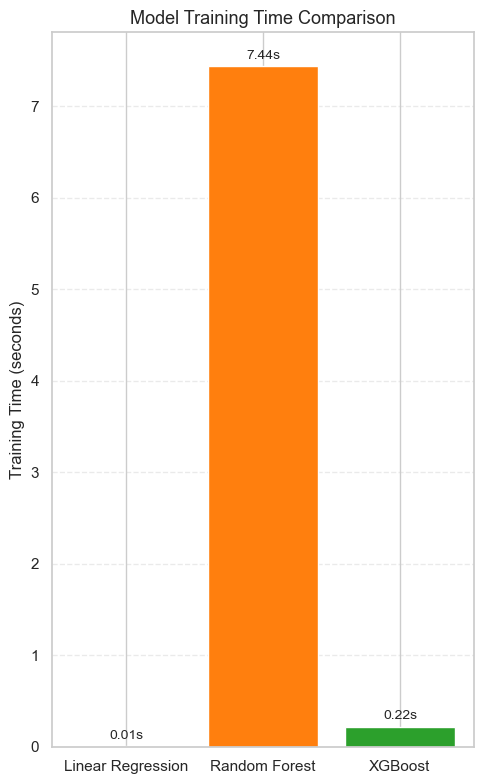

In [50]:
plt.figure(figsize=(5,8))

models = ['Linear Regression', 'Random Forest', 'XGBoost']
times = [total_seconds_lr, total_seconds_rf, total_seconds_xgb]

bars = plt.bar(models, times, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title("Model Training Time Comparison", fontsize=13)
plt.ylabel("Training Time (seconds)")

# Tambahkan angka di atas batang
for bar, time in zip(bars, times):
    plt.text(bar.get_x() + bar.get_width()/2, time + 0.05, f"{time:.2f}s", 
             ha='center', va='bottom', fontsize=10)

# Relative training time (time ratio)
baseline = total_seconds_lr
ratios = [t / baseline for t in times]

for m, r in zip(models, ratios):
    if r > 1:
        print(f"{m}: {r:.2f}× slower than Linear Regression")
    elif r < 1:
        print(f"{m}: {1/r:.2f}× faster than Linear Regression")
    else:
        print(f"{m}: baseline (same as Linear Regression)")

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Feature Importance

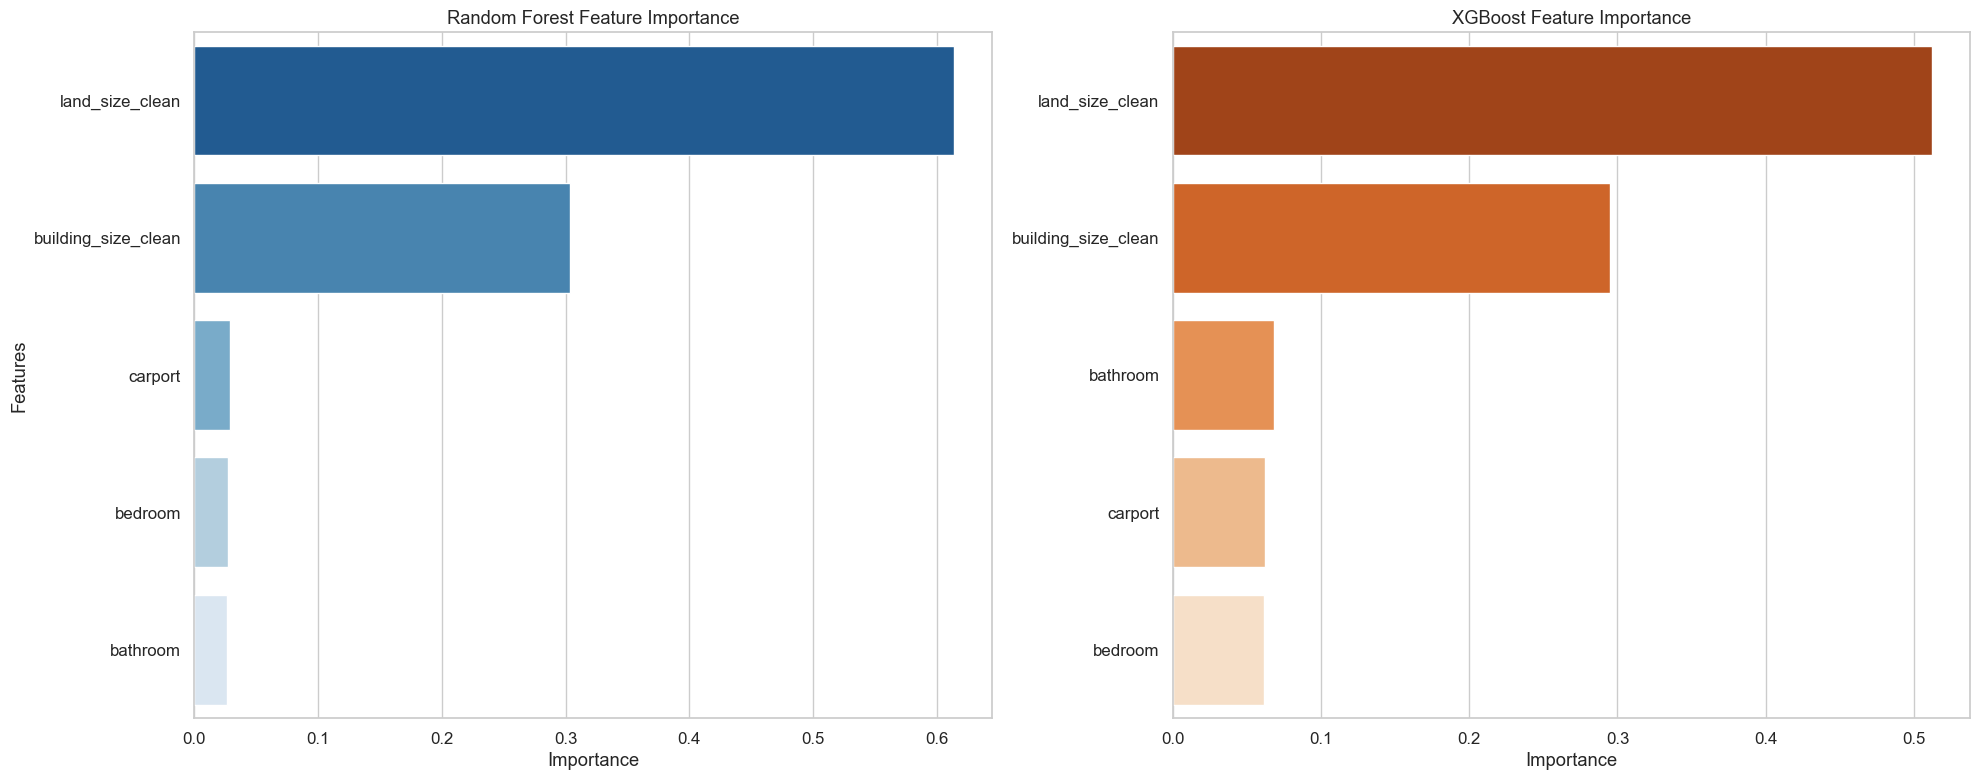

In [51]:
# Setup style
sns.set(style="whitegrid", font_scale=1.1)

fig, ax = plt.subplots(1, 2, figsize=(20, 8))

# Random Forest Feature Importance 
rf_features = pd.DataFrame({
    'Features': X_train.columns,
    'Importance': best_grid_rf.feature_importances_
})
rf_features.sort_values('Importance', ascending=False, inplace=True)

sns.barplot(
    x='Importance',
    y='Features',
    data=rf_features,
    palette="Blues_r",
    hue='Features',
    legend=False,
    ax=ax[0]
)
ax[0].set_title('Random Forest Feature Importance')
ax[0].set_xlabel('Importance')
ax[0].set_ylabel('Features')

# XGBoost Feature Importance 
xgb_features = pd.DataFrame({
    'Features': X_train.columns,
    'Importance': best_grid_xgb.feature_importances_
})
xgb_features.sort_values('Importance', ascending=False, inplace=True)

sns.barplot(
    x='Importance',
    y='Features',
    data=xgb_features,
    palette="Oranges_r",
    hue='Features',
    legend=False,
    ax=ax[1]
)
ax[1].set_title('XGBoost Feature Importance')
ax[1].set_xlabel('Importance')
ax[1].set_ylabel('')

# Layout
plt.tight_layout()
plt.show()

The feature importance plots show that both Random Forest and XGBoost identify land size and building size as the most influential factors in predicting house prices. While Random Forest relies more heavily on land size, XGBoost distributes importance more evenly and gives slightly higher weight to features like bathroom, carport, and bedroom, reflecting better capture of nonlinear effects. Overall, property dimensions remain the strongest predictors across both models.

# Predicting the price of new house using trained model

In [52]:
# Predicting prices for multiple sample houses
# Data Extracted from real-world listing (rumah123.com)
houses = pd.DataFrame([
    {
        'name': 'Rumah 1',
        'actual_price': 2500000000,
        'bedroom': 3,
        'bathroom': 2,
        'carport': 1,
        'land_size_clean': 188,
        'building_size_clean': 110
    },
    {
        'name': 'Rumah 2',
        'actual_price': 2250000000,
        'bedroom': 3,
        'bathroom': 3,
        'carport': 1,
        'land_size_clean': 183,
        'building_size_clean': 300
    },
    {
        'name': 'Rumah 3',
        'actual_price': 850000000,
        'bedroom': 2,
        'bathroom': 2,
        'carport': 0,
        'land_size_clean': 88,
        'building_size_clean': 70
    },
    {
        'name': 'Rumah 4',
        'actual_price': 966000000,
        'bedroom': 4,
        'bathroom': 3,
        'carport': 1,
        'land_size_clean': 60,
        'building_size_clean': 90
    },
    {
        'name': 'Rumah 5',
        'actual_price': 1880000000,
        'bedroom': 3,
        'bathroom': 2,
        'carport': 0,
        'land_size_clean': 126,
        'building_size_clean': 93
    }
])

# Feature for prediction
X_new = houses[['bedroom', 'bathroom', 'carport', 'land_size_clean', 'building_size_clean']]

# Make Prediction
houses['Pred_Linear'] = pipe.predict(X_new)
houses['Pred_RF'] = best_grid_rf.predict(X_new)
houses['Pred_XGB'] = best_grid_xgb.predict(X_new)

# Format Price
def format_rupiah(x):
    return f"Rp {x:,.0f}".replace(",", ".")

houses['Actual_Price'] = houses['actual_price'].apply(format_rupiah)
houses['Linear_Price_Prediction'] = houses['Pred_Linear'].apply(format_rupiah)
houses['RandomForest_Price_Prediction'] = houses['Pred_RF'].apply(format_rupiah)
houses['XGBoost_Price_Prediction'] = houses['Pred_XGB'].apply(format_rupiah)

# Tampilkan hasil
houses_display = houses[['name', 'Actual_Price', 'Linear_Price_Prediction', 'RandomForest_Price_Prediction', 'XGBoost_Price_Prediction']]
display(houses_display)

,name,Actual_Price,Linear_Price_Prediction,RandomForest_Price_Prediction,XGBoost_Price_Prediction
0,Rumah 1,Rp 2.500.000.000,Rp 2.074.747.863,Rp 2.332.156.530,Rp 1.798.952.192
1,Rumah 2,Rp 2.250.000.000,Rp 3.437.444.813,Rp 2.990.549.868,Rp 3.080.115.712
2,Rumah 3,Rp 850.000.000,Rp 968.626.654,Rp 941.574.921,Rp 985.810.816
3,Rumah 4,Rp 966.000.000,Rp 953.408.290,Rp 1.018.102.174,Rp 920.595.328
4,Rumah 5,Rp 1.880.000.000,Rp 1.392.116.685,Rp 1.409.679.550,Rp 1.358.982.400


## Conclusion

From the analysis, it can be observed that the XGBoost Regression model achieved the highest overall accuracy, with an R2 score of 0.7838, slightly outperforming Random Forest Regression (0.7765).
However, further evaluation through residual and distribution plots revealed that Random Forest produced more stable and well-calibrated predictions, with error values more tightly centered around zero and smoother alignment with the actual price distribution.

During model testing using unseen real-world data, the Random Forest model generated price predictions closer to the actual property listings, demonstrating stronger generalization and lower variance compared to XGBoost.
This indicates that while XGBoost captures nonlinear relationships more aggressively, it may be slightly overfitted to the training data, whereas Random Forest offers a more balanced and consistent performance.

In conclusion, both ensemble models significantly outperform Linear Regression, with XGBoost excelling in in-sample accuracy and Random Forest standing out for its real-world reliability and stable predictive behavior.
These findings suggest that Random Forest serves as a dependable baseline for automated house price estimation systems, while XGBoost can be leveraged for further optimization with careful regularization and feature refinement.